# Statistics for Michel electron candidate (Update for cosmic run 28116)

### Created by Shu, 20250920---

#### To explore decay points distribution asymmetry along drift direction

#### (20250916) Main update here is the introduction of CLASS, to upgrade current cumbersome data processing

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Initial candidates:

In [18]:
from dataclasses import dataclass

@dataclass
class ParticleEvent:
    decayX_initial: float = None
    decayY_initial: float = None
    decayZ_initial: float = None
    startX_initial: float = None
    startY_initial: float = None
    startZ_initial: float = None
    MS_initial: float = None
    MH_initial: float = None
    eventID_initial: int = None
    trackID_initial: int = None


def read_values(file_path, cast_type=float):
    values = []
    with open(file_path, 'r') as filehandle:
        for line in filehandle:
            value = line.strip()
            if value:
                values.append(cast_type(value))
    return values


def read_multiple(files, cast_type=float):
    """Read multiple text files in sequence and combine into one list."""
    values = []
    for f in files:
        values.extend(read_values(f, cast_type=cast_type))
    return values


# --- Updated multiple-file reading (all in ./statResult_20250828) ---

decayX_initial = read_multiple([
    './statResult_tpc/decayX_initial.txt'
])

decayY_initial = read_multiple([
    './statResult_tpc/decayY_initial.txt'
])

decayZ_initial = read_multiple([
    './statResult_tpc/decayZ_initial.txt'
])

startX_initial = read_multiple([
    './statResult_tpc/startX_initial.txt'
])

startY_initial = read_multiple([
    './statResult_tpc/startY_initial.txt'
])

startZ_initial = read_multiple([
    './statResult_tpc/startZ_initial.txt'
])

MS_initial = read_multiple([
    './statResult_tpc/michelScore_initial.txt'
])

MH_initial = read_multiple([
    './statResult_tpc/michelHits_initial.txt'
])

eventID_initial = read_multiple([
    './statResult_tpc/eventID_initial.txt'
], cast_type=int)

trackID_initial = read_multiple([
    './statResult_tpc/trackID_initial.txt'
], cast_type=int)




#initial total events---
events_reco = []
for i in range(len(decayX_initial)):
    event = ParticleEvent(
        decayX_initial = decayX_initial[i],
        decayY_initial = decayY_initial[i],
        decayZ_initial = decayZ_initial[i],
        startX_initial = startX_initial[i],
        startY_initial = startY_initial[i],
        startZ_initial = startZ_initial[i],
        MS_initial = MS_initial[i],
        MH_initial = MH_initial[i],
        eventID_initial   = eventID_initial[i],
        trackID_initial = trackID_initial[i]
    )
    events_reco.append(event)


print("Candidates ( MS > 0.01): ", len(events_reco))

print("\nExample: ")
print(events_reco[0].decayX_initial)
print(events_reco[0].decayY_initial)
print(events_reco[0].eventID_initial)





Candidates ( MS > 0.01):  125270

Example: 
19.165
102.242
1220



Decay points distribution: 
# of X < 0 :  84537 (67.48%)
# of X >= 0:  40733 (32.52%)


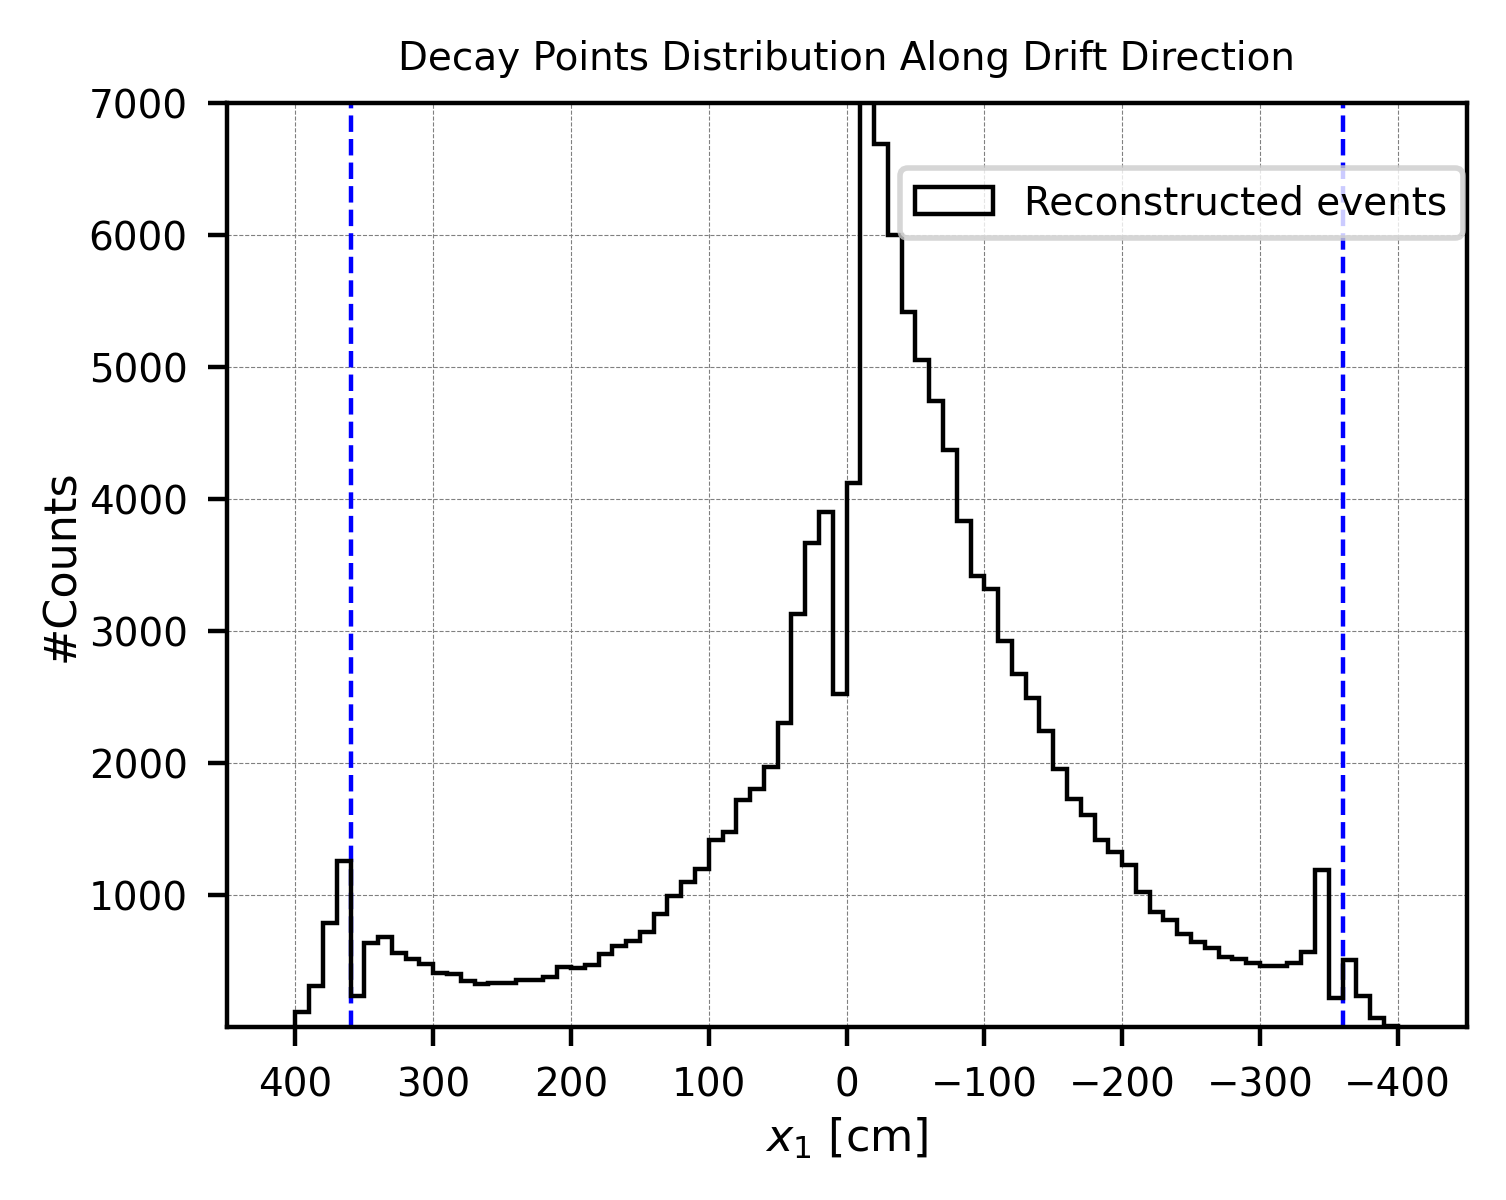

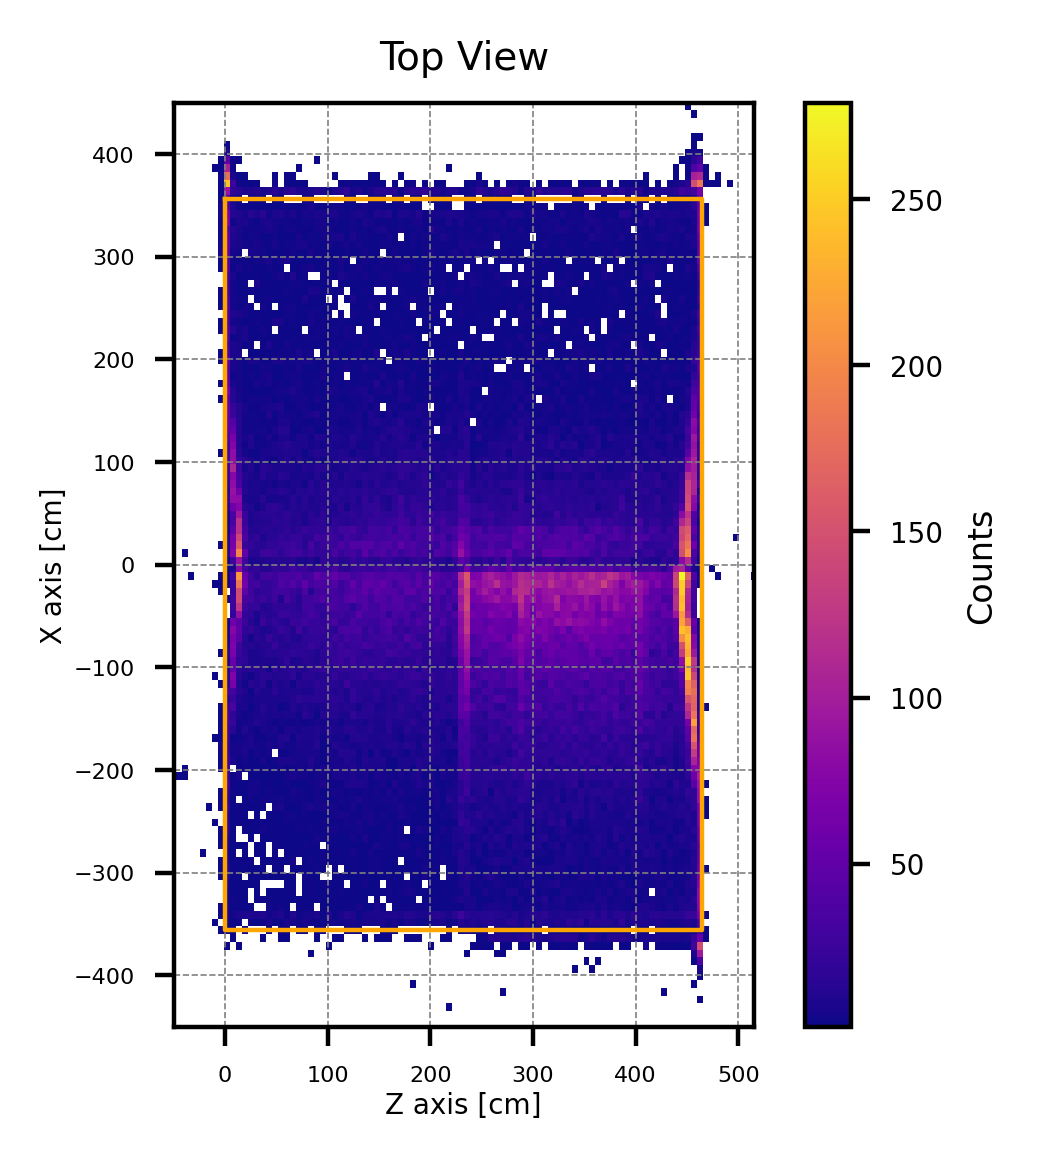

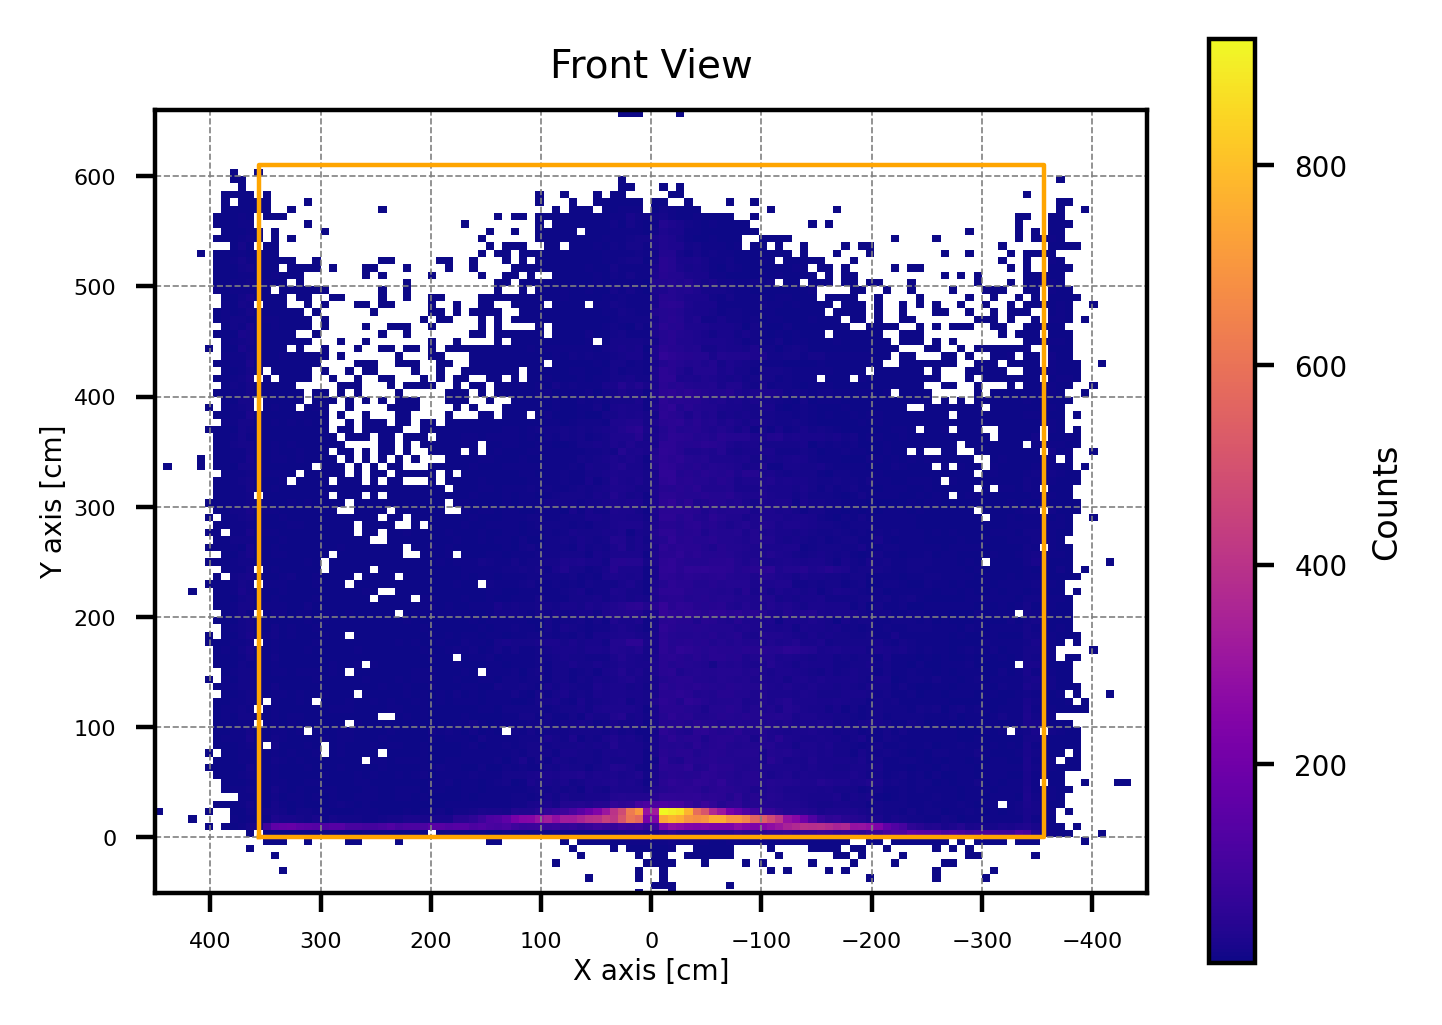

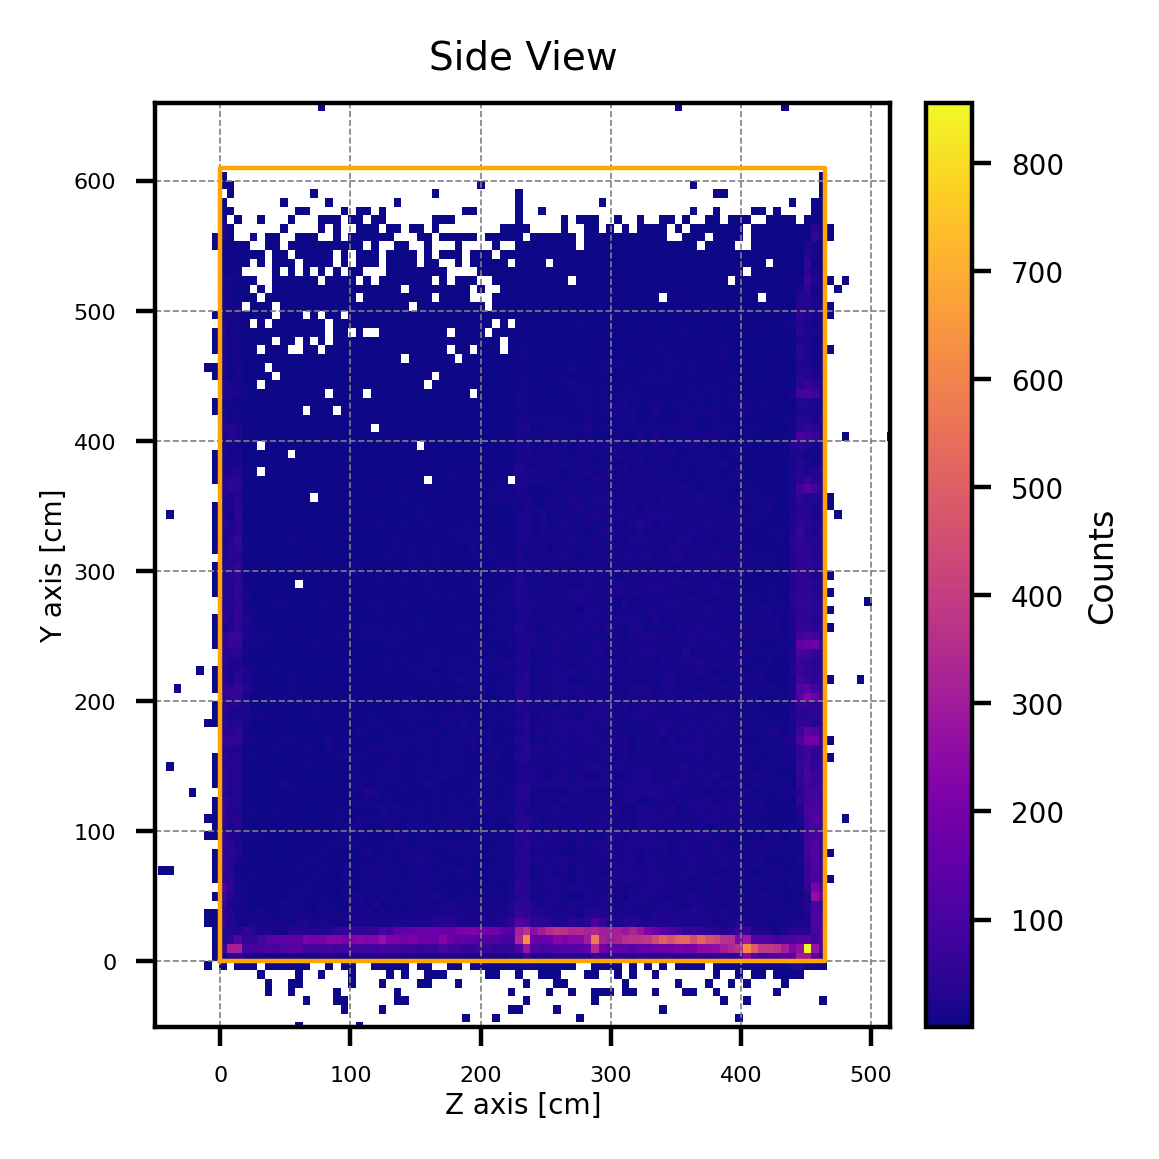

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



#Initial values:
vals_decayX_initial = [ev.decayX_initial for ev in events_reco]
vals_decayY_initial = [ev.decayY_initial for ev in events_reco]
vals_decayZ_initial = [ev.decayZ_initial for ev in events_reco]

vals_startX_initial = [ev.startX_initial for ev in events_reco]
vals_startY_initial = [ev.startY_initial for ev in events_reco]
vals_startZ_initial = [ev.startZ_initial for ev in events_reco]

vals_MS_initial = [ev.MS_initial for ev in events_reco]
vals_MH_initial = [ev.MH_initial for ev in events_reco]





#Decay points distribution:==========================================
print("\nDecay points distribution: ")

decayX_initial = np.array(decayX_initial)
neg_X = np.sum(decayX_initial < 0)
pos_X = np.sum(decayX_initial >= 0)

num_negX = len([ev for ev in events_reco if ev.decayX_initial < 0])
num_posX = len([ev for ev in events_reco if ev.decayX_initial > 0])

print("# of X < 0 : ", num_negX, "({:.2f}%)".format(num_negX/len(events_reco)*100))
print("# of X >= 0: ", num_posX, "({:.2f}%)".format(num_posX/len(events_reco)*100))



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 7000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 7000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)


plt.hist(vals_decayX_initial, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 7000)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayX_initial, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayX_initial, vals_decayY_initial, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayY_initial, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 












#### Starting Points Distribution:

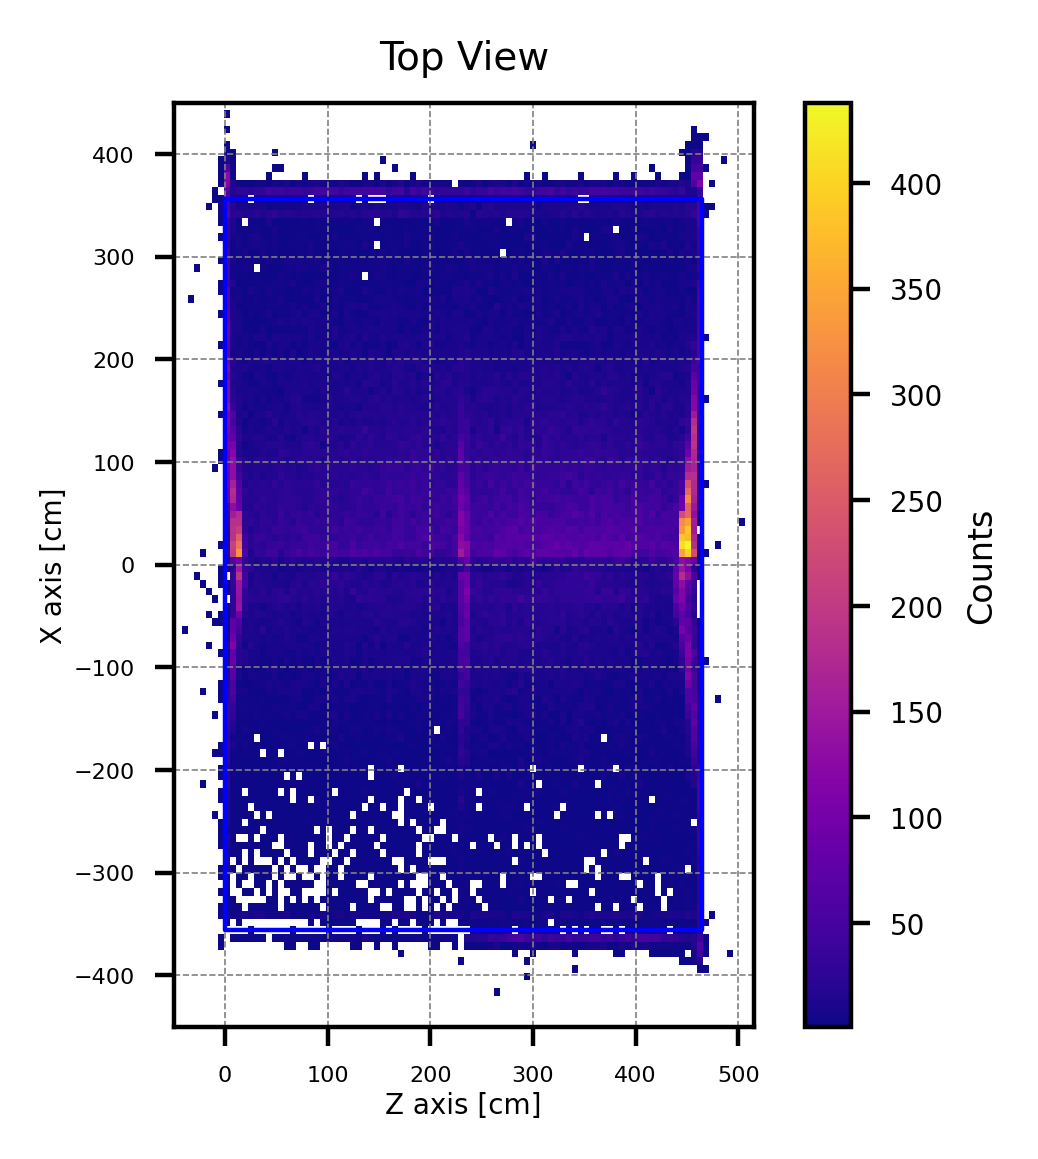

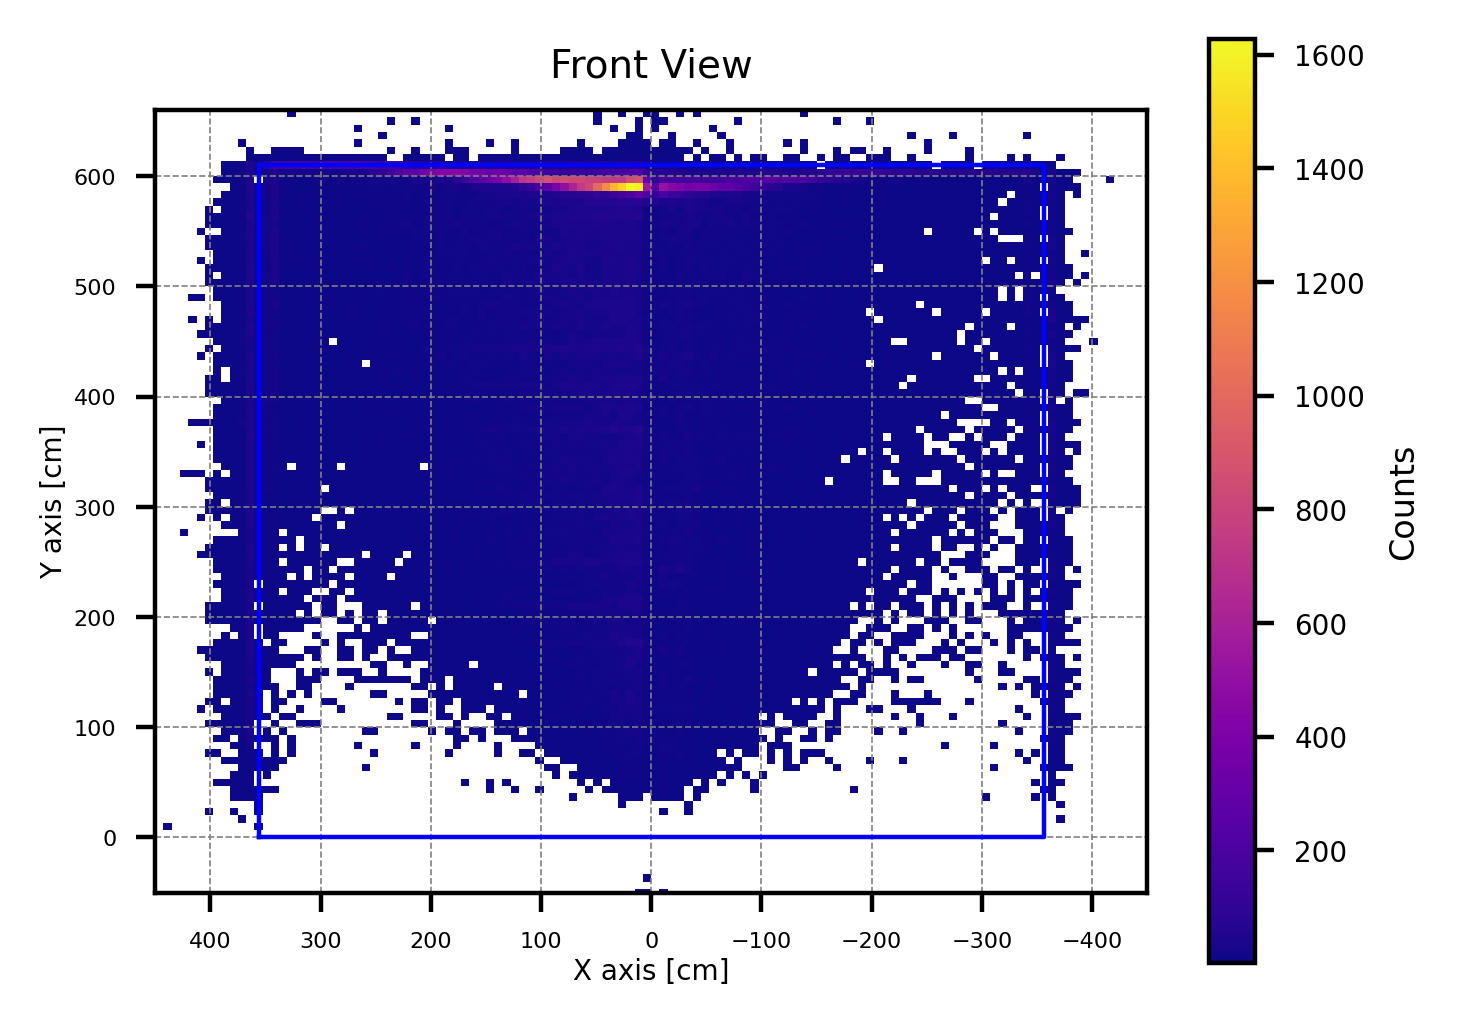

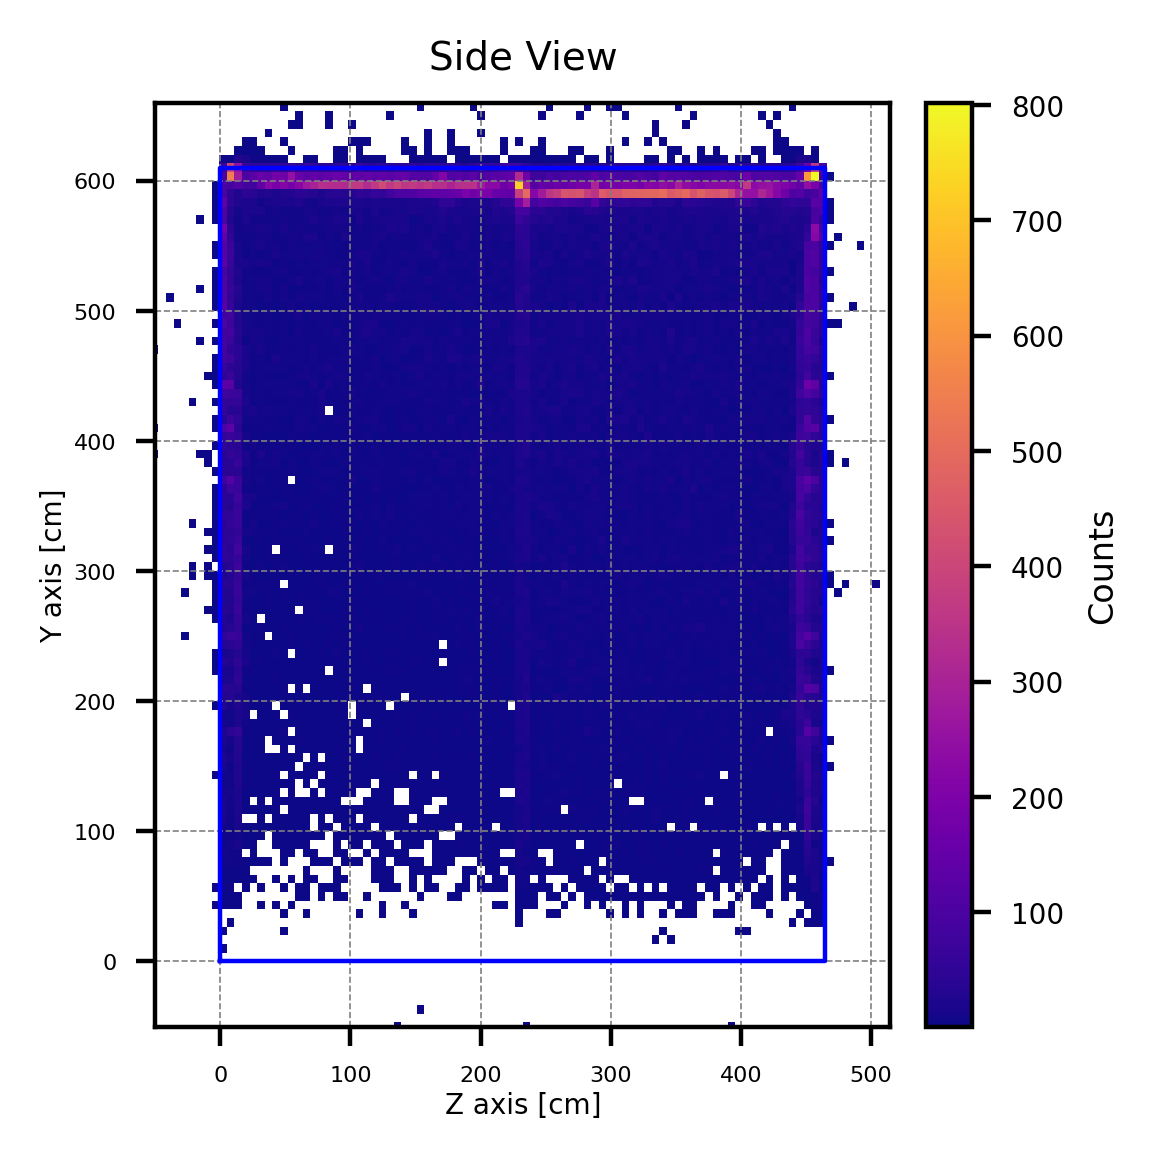

In [20]:
#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_startZ_initial, vals_startX_initial, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_startX_initial, vals_startY_initial, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_startZ_initial, vals_startY_initial, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 

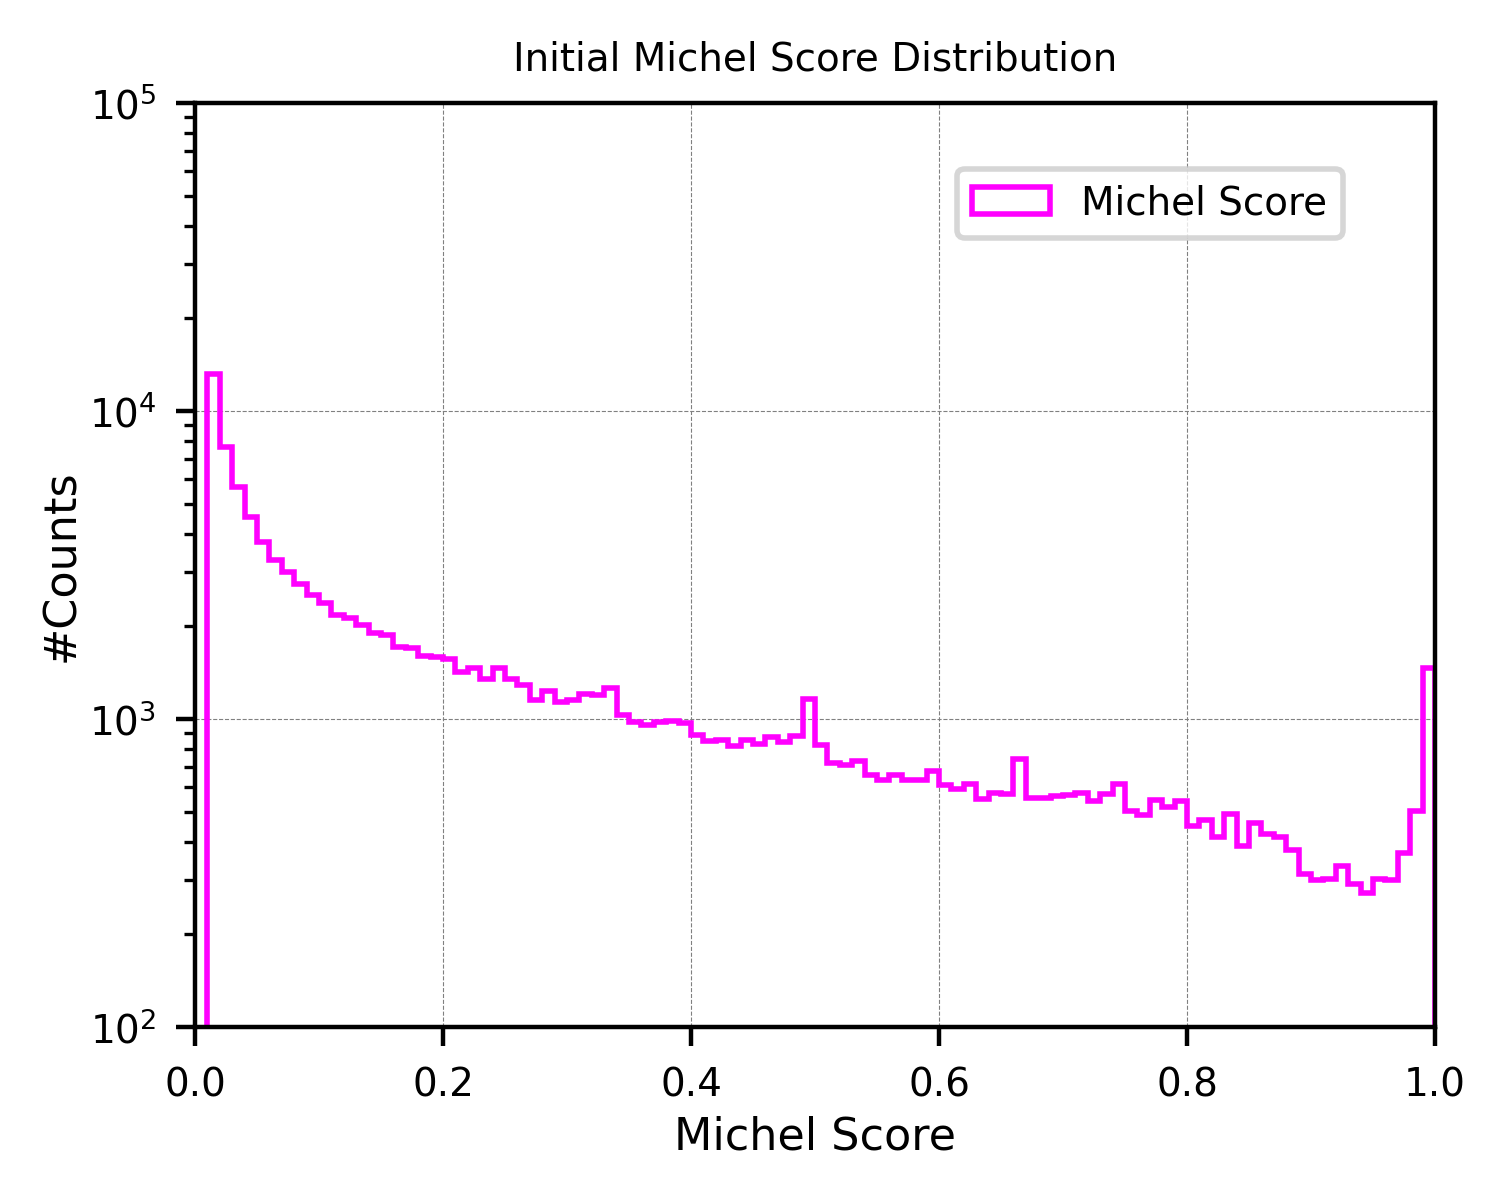

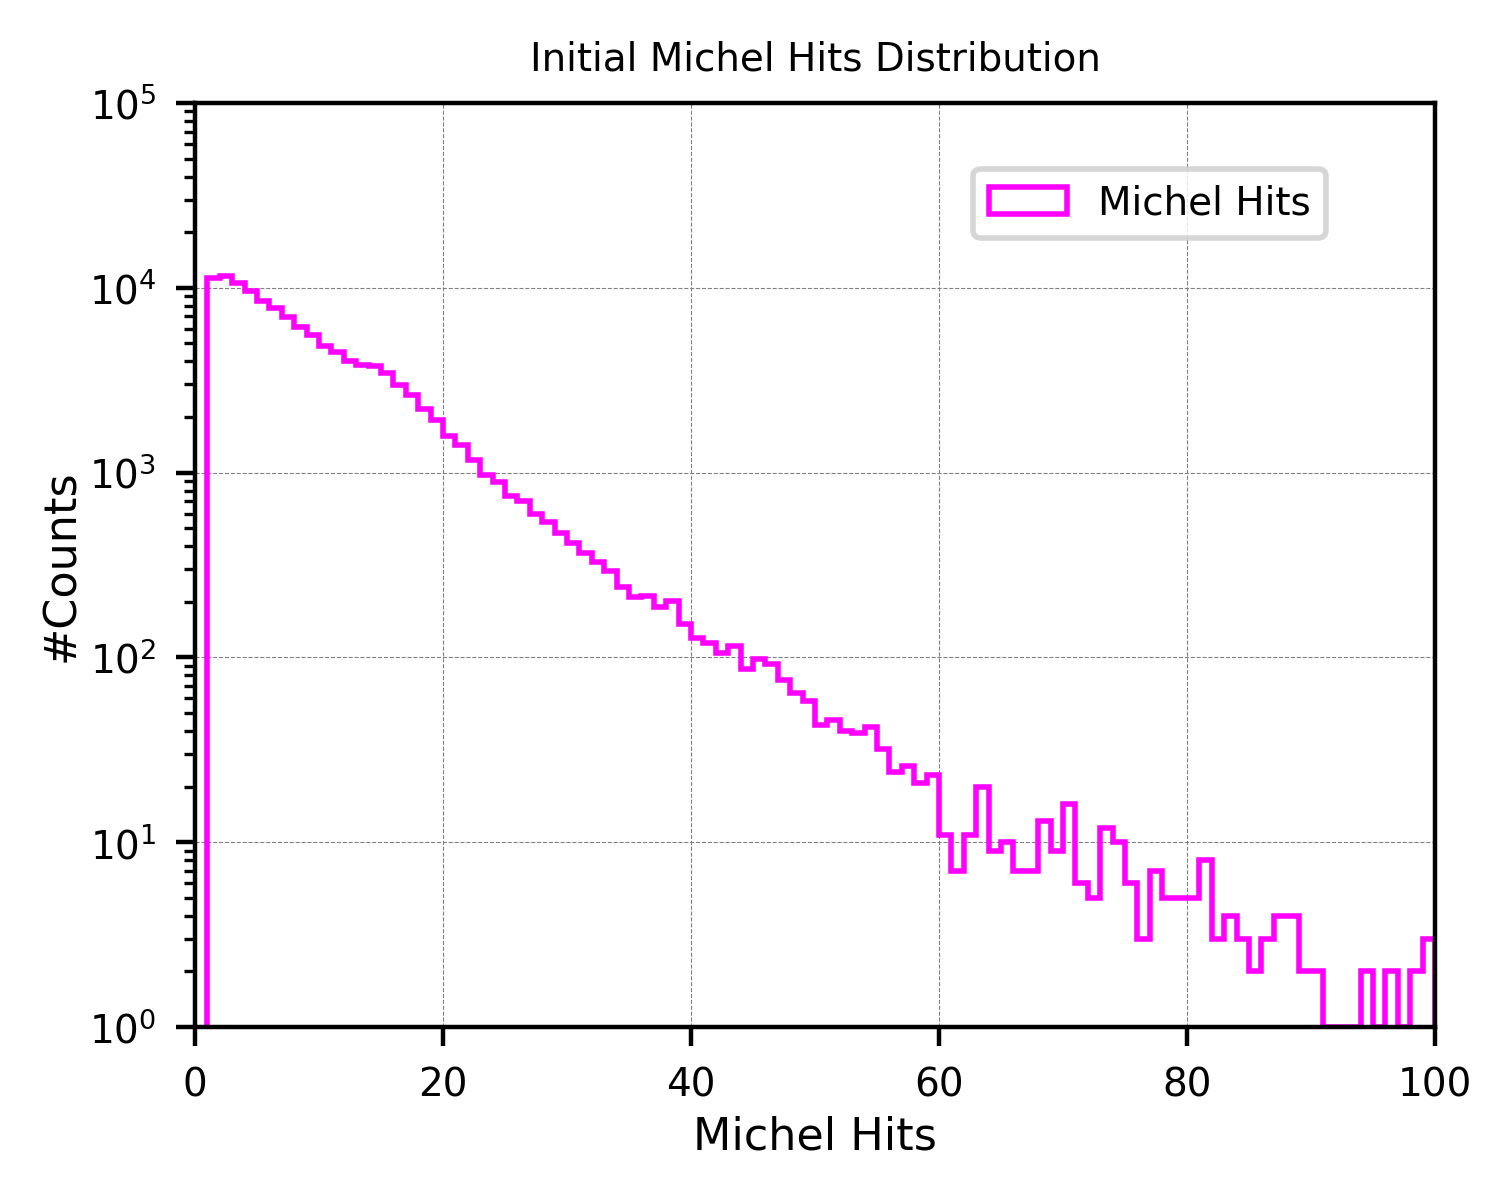

In [21]:

# Michel Score--------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)


plt.hist(vals_MS_initial, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=1.0, label="Michel Score")


plt.xlim(0, 1.0)
plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(100, 100000)
plt.yscale('log')
plt.title('Initial Michel Score Distribution', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  





# Michel Hits--------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)


plt.hist(vals_MH_initial, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=1.0, label="Michel Hits")


plt.xlim(0, 100)
plt.xlabel('Michel Hits', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(1, 100000)
plt.yscale('log')
plt.title('Initial Michel Hits Distribution', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  



<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## TPC cuts:


### Apply cuts gradually:

In [22]:
Space_events_reco = []
MS_events_reco = []
MH_events_reco = [] # After Space & MS & MH cuts---



#Selection------
for ev in events_reco:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    MS = ev.MS_initial
    MH = ev.MH_initial

        
    #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
    if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    
        Space_events_reco.append(ev)

        if 0.3 < MS: #(Michel score cut)---
            MS_events_reco.append(ev)
            
            if 3 <MH: #Michel hits cut---                
                MH_events_reco.append(ev)
                    
                    
                    

                    
#Initial size of dataset:-----
print("Reco events (initial): ", len(events_reco))

print("\nReco events (Space cut): ", len(Space_events_reco), "({:.2f}%)".format(len(Space_events_reco)/len(events_reco)*100))

print("\nReco events (Space & MS cuts): ", len(MS_events_reco), "({:.2f}%)".format(len(MS_events_reco)/len(events_reco)*100))

print("\nReco events (Space & MS & MH cuts): ", len(MH_events_reco), "({:.2f}%)".format(len(MH_events_reco)/len(events_reco)*100))





Reco events (initial):  125270

Reco events (Space cut):  49449 (39.47%)

Reco events (Space & MS cuts):  19658 (15.69%)

Reco events (Space & MS & MH cuts):  16962 (13.54%)



### Apply all cuts:

In [23]:

TPC_events_reco = [] # After Space & MS & MH cuts---



#Selection------
for ev in events_reco:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    MS = ev.MS_initial
    MH = ev.MH_initial

        
    #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
    if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    

        if 0.3 < MS: #(Michel score cut)---
            
            if 3 <MH: #Michel hits cut---                
                TPC_events_reco.append(ev)


print("\nReco events (Space & MS & MH cuts): ", len(TPC_events_reco), 
      "({:.2f}%)".format(len(TPC_events_reco)/len(events_reco)*100))




Reco events (Space & MS & MH cuts):  16962 (13.54%)


Decay points distribution (After TPC cut): 
# of X < 0 :  12820 (75.581%)
# of X >= 0:  4142 (24.419%)

#decayX_TPC (total):  16962
#decayX_apa1:  2555 (15.06%)
#decayX_apa2:  10265 (60.52%)
#decayX_apa3:  1913 (11.28%)
#decayX_apa4:  2229 (13.14%)


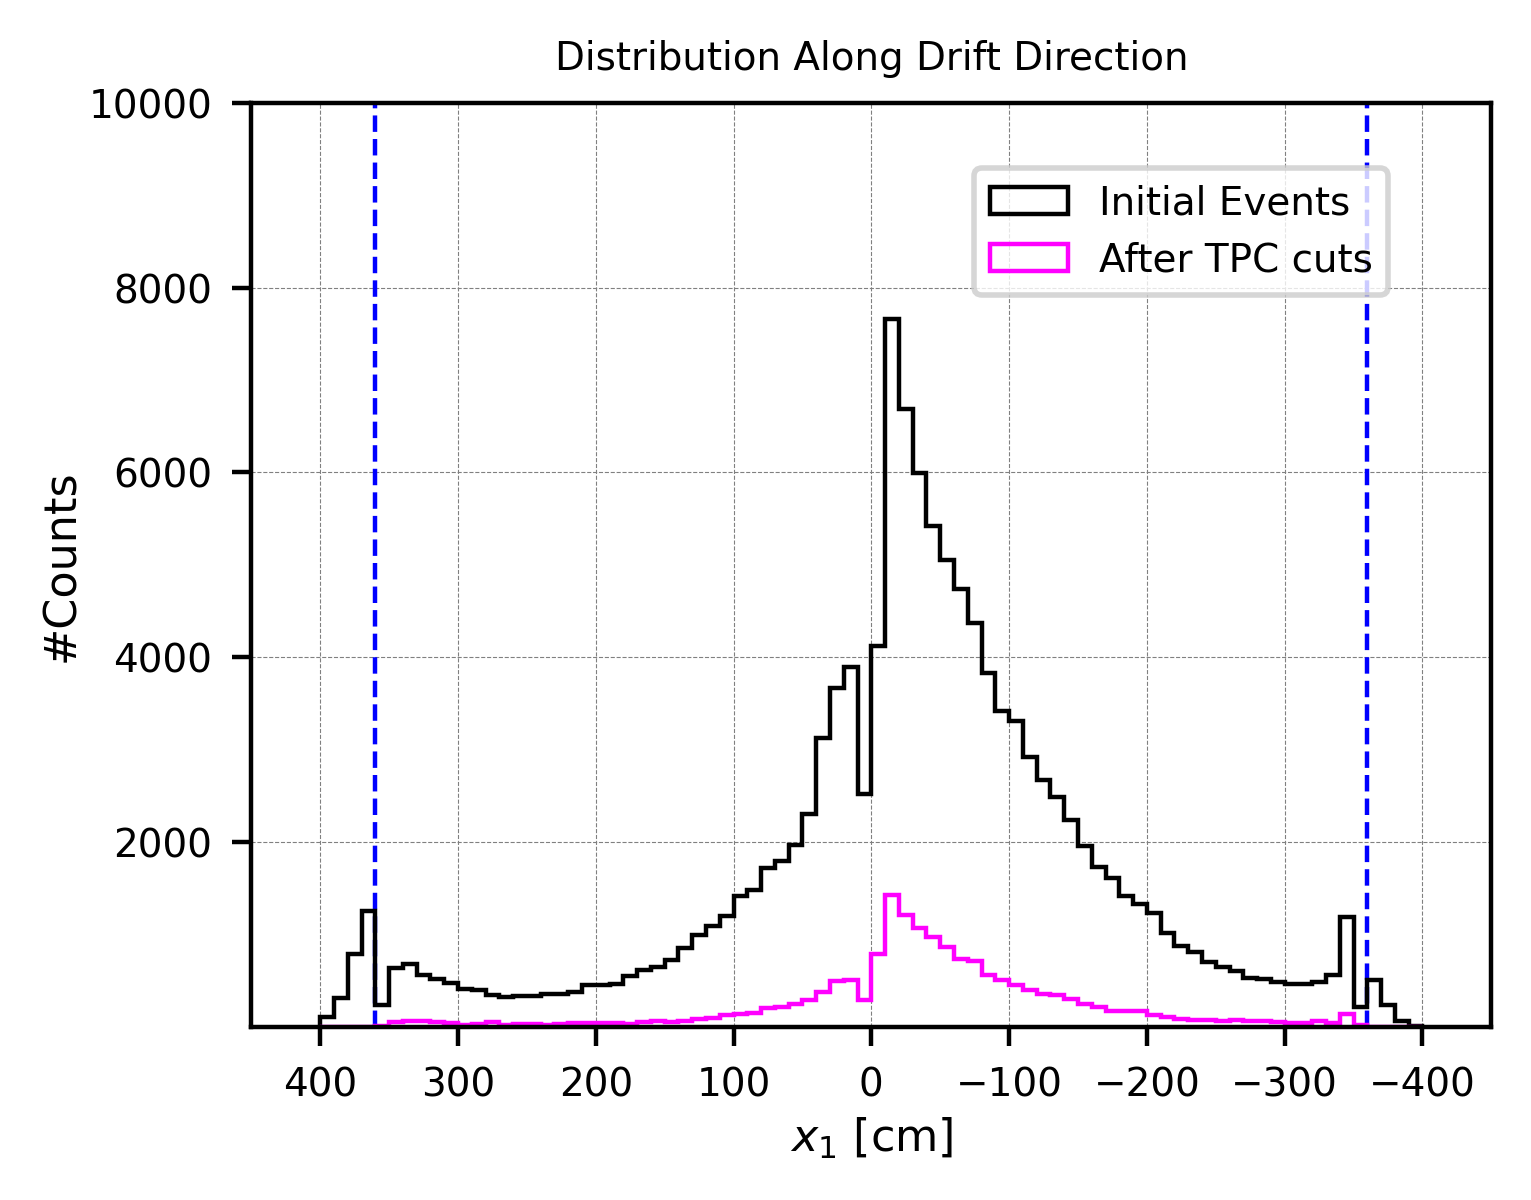

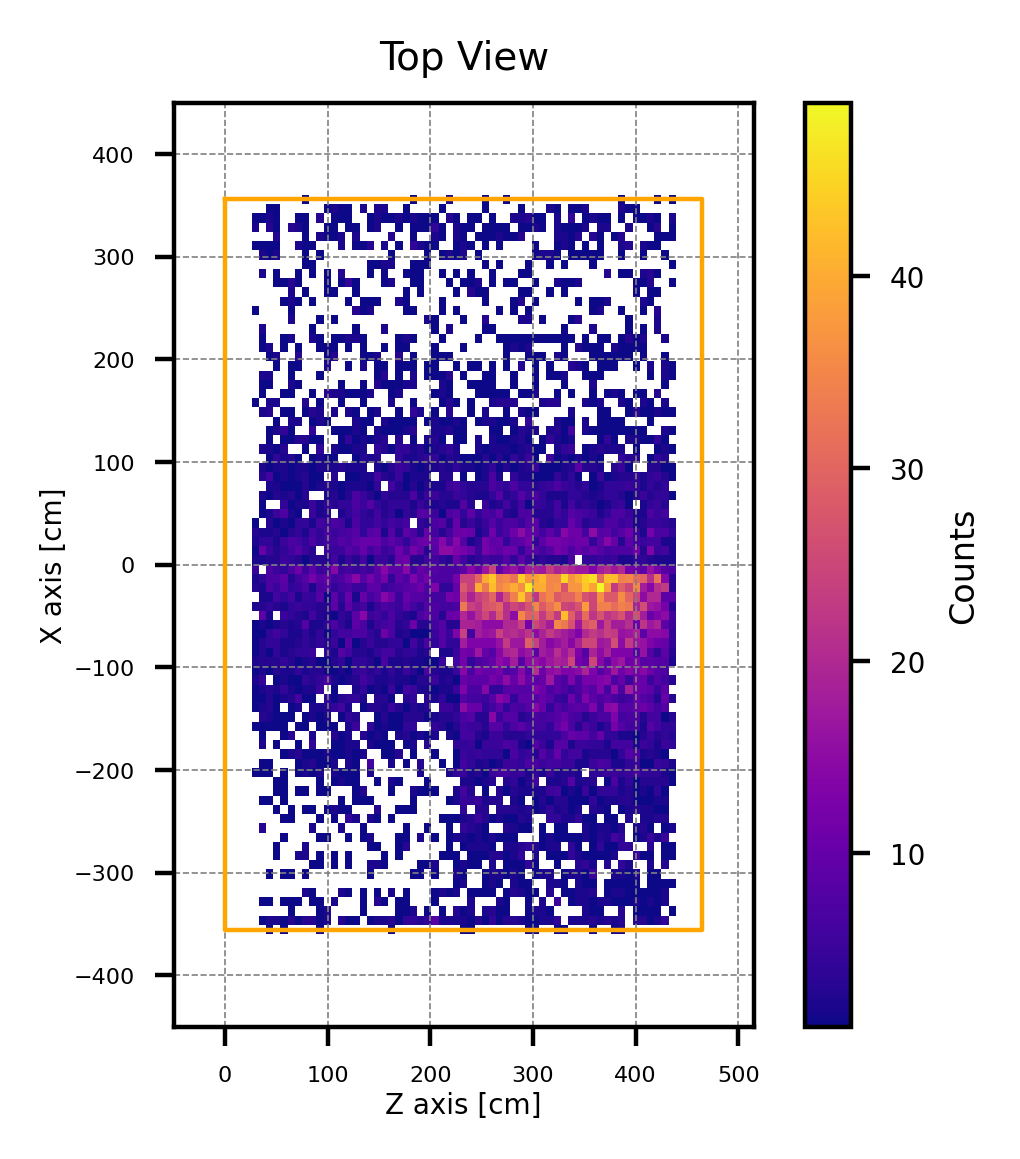

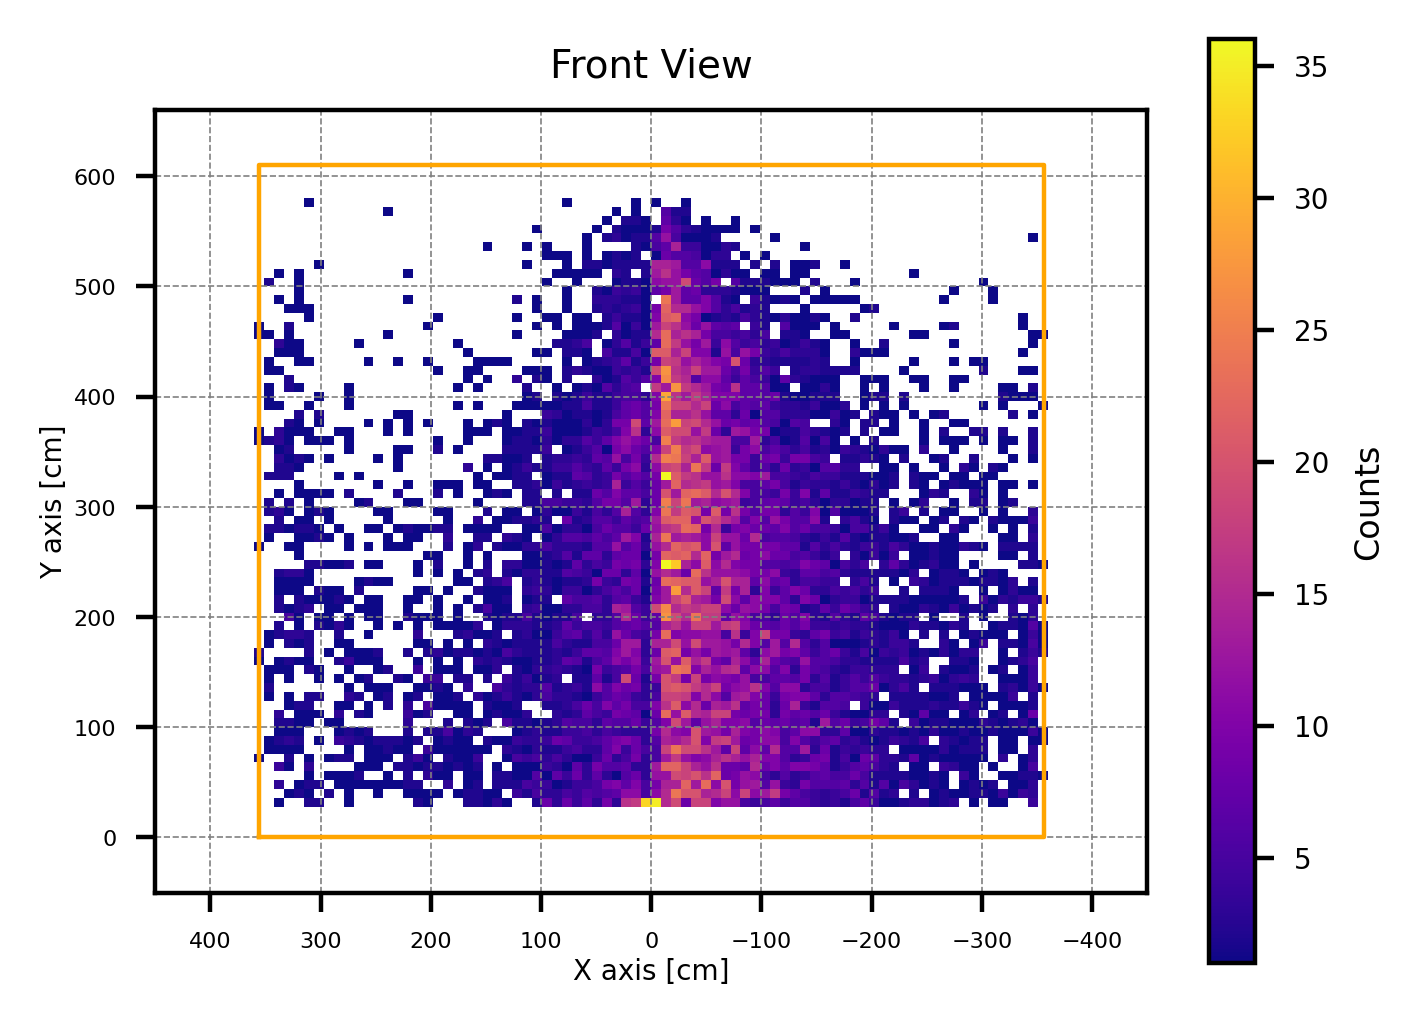

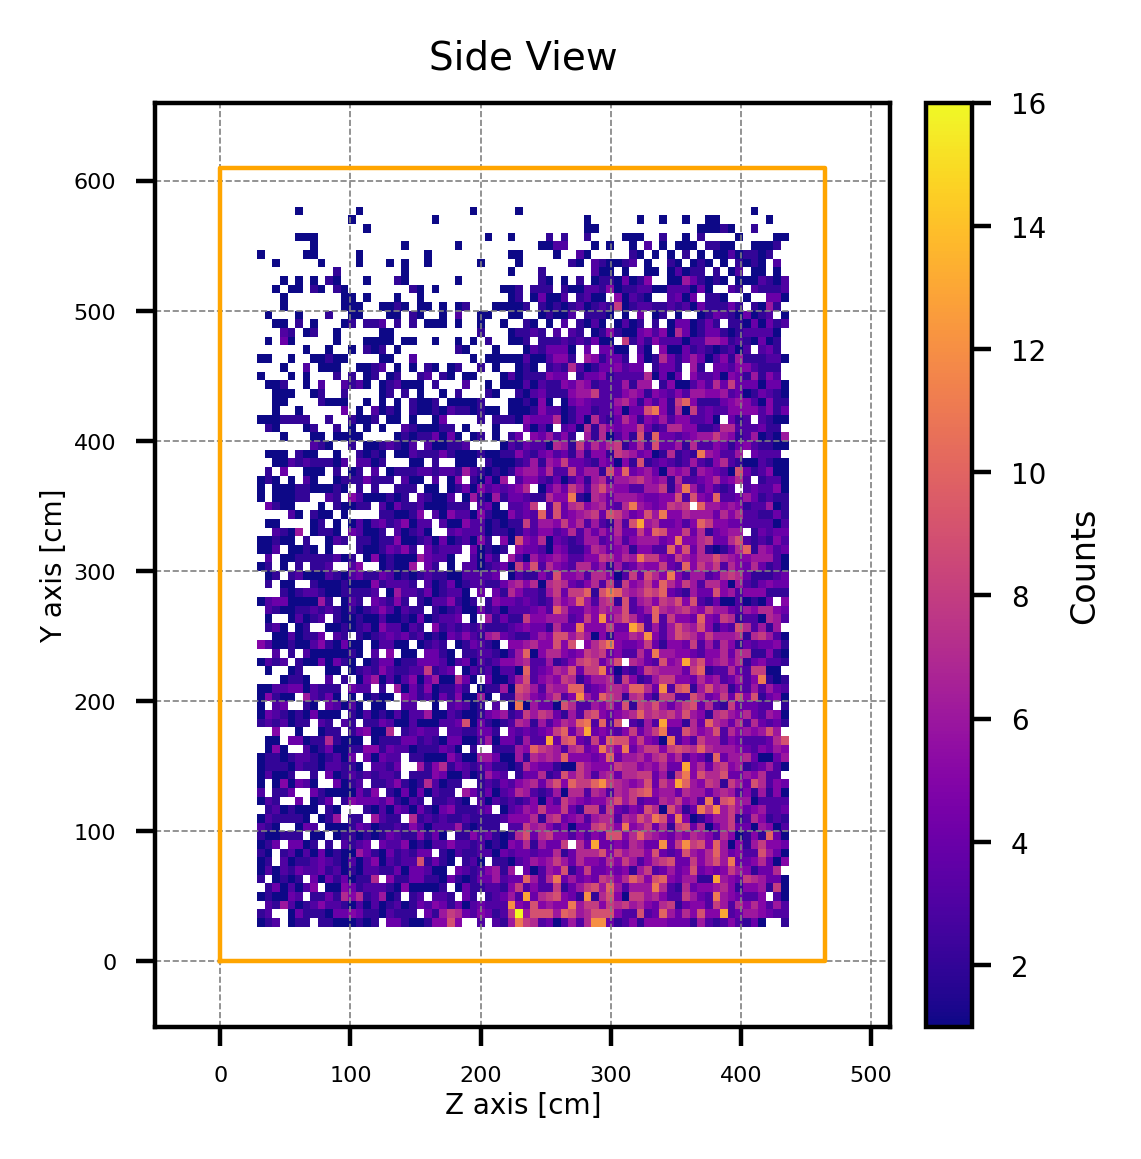

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



TPC_X = [ev.decayX_initial for ev in TPC_events_reco]
TPC_Y = [ev.decayY_initial for ev in TPC_events_reco]
TPC_Z = [ev.decayZ_initial for ev in TPC_events_reco]
TPC_MS = [ev.MS_initial for ev in TPC_events_reco]
TPC_MH = [ev.MH_initial for ev in TPC_events_reco]
TPC_startX = [ev.startX_initial for ev in TPC_events_reco]
TPC_startZ = [ev.startZ_initial for ev in TPC_events_reco]
TPC_startY = [ev.startY_initial for ev in TPC_events_reco]



#Decay points distribution:==========================================
print("Decay points distribution (After TPC cut): ")

TPC_X = np.array(TPC_X)
neg_X = np.sum(TPC_X < 0)
pos_X = np.sum(TPC_X >= 0)
print("# of X < 0 : ", neg_X, "({:.3f}%)".format(neg_X/len(TPC_X)*100))
print("# of X >= 0: ", pos_X, "({:.3f}%)".format(pos_X/len(TPC_X)*100))



#Decay points in 4 APA regions:==========================================
decayX_apa1 = []
decayX_apa2 = []
decayX_apa3 = []
decayX_apa4 = []

decayZ_apa1 = []
decayZ_apa2 = []
decayZ_apa3 = []
decayZ_apa4 = []

#Do seperation:
for i in range(0, len(TPC_X)):
    z = TPC_Z[i]
    x = TPC_X[i]

    if x <= 0 and z <= 231.266: #APA1
        decayX_apa1.append(x)
        decayZ_apa1.append(z)              
    elif x <= 0 and z > 231.266: #APA2
        decayX_apa2.append(x)
        decayZ_apa2.append(z)        
    elif x > 0 and z <= 231.266: #APA3
        decayX_apa3.append(x)
        decayZ_apa3.append(z) 
    elif x > 0 and z > 231.266: #APA4
        decayX_apa4.append(x)
        decayZ_apa4.append(z) 


print("\n#decayX_TPC (total): ", len(TPC_X))
print("#decayX_apa1: ", len(decayX_apa1), "({:.2f}%)".format(len(decayX_apa1)/len(TPC_X)*100))
print("#decayX_apa2: ", len(decayX_apa2), "({:.2f}%)".format(len(decayX_apa2)/len(TPC_X)*100))
print("#decayX_apa3: ", len(decayX_apa3), "({:.2f}%)".format(len(decayX_apa3)/len(TPC_X)*100))
print("#decayX_apa4: ", len(decayX_apa4), "({:.2f}%)".format(len(decayX_apa4)/len(TPC_X)*100))








#Decay points distribution:==========================================



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 10000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 10000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)


plt.hist(vals_decayX_initial, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Initial Events")
plt.hist(TPC_X, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8, label="After TPC cuts")


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 10000)
#plt.yscale('log')
plt.title('Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_X, bins=(100, 100), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_X, TPC_Y, bins=(100, 100), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 








#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_Y, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 





#### Starting Point Distribution:

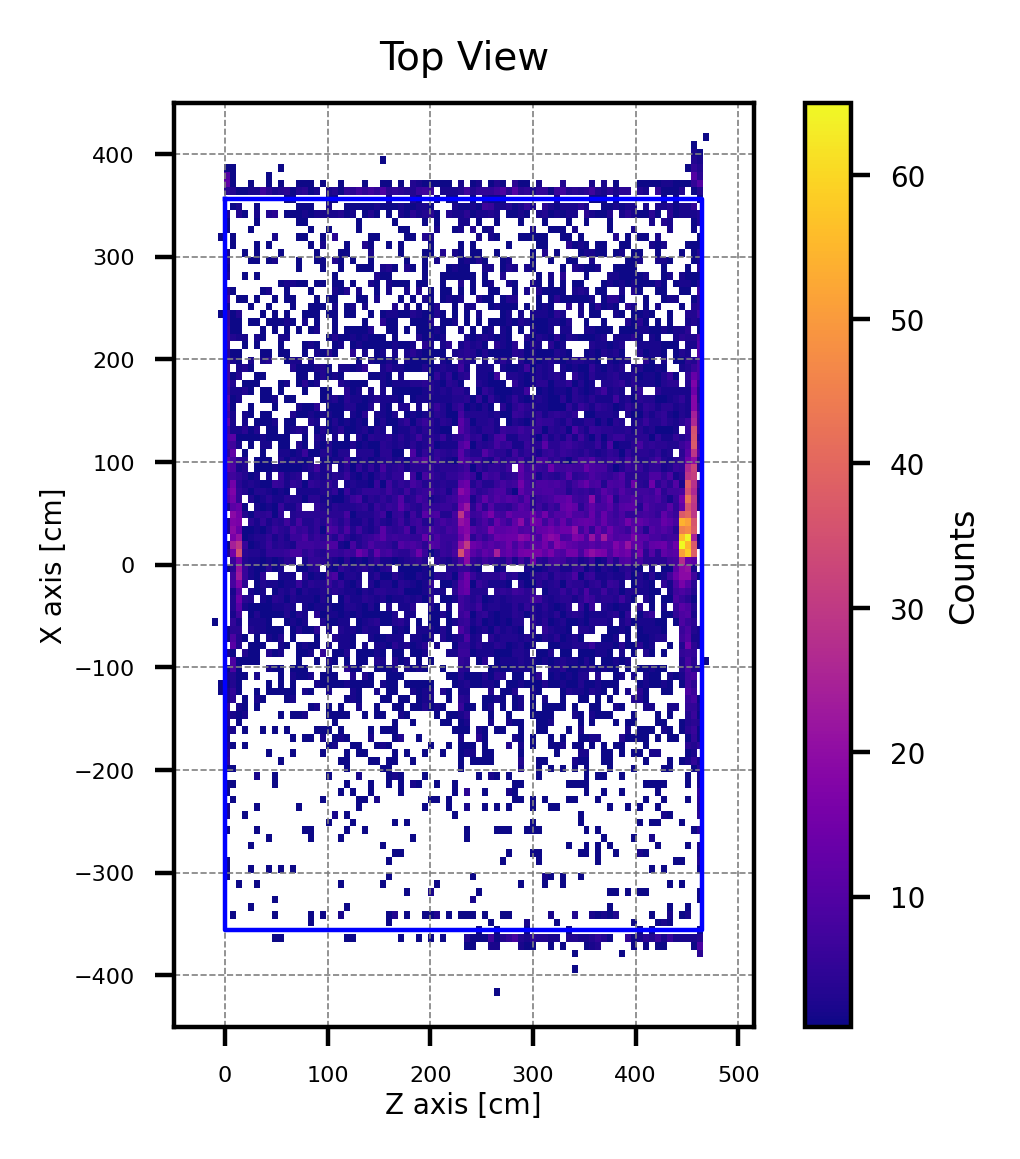

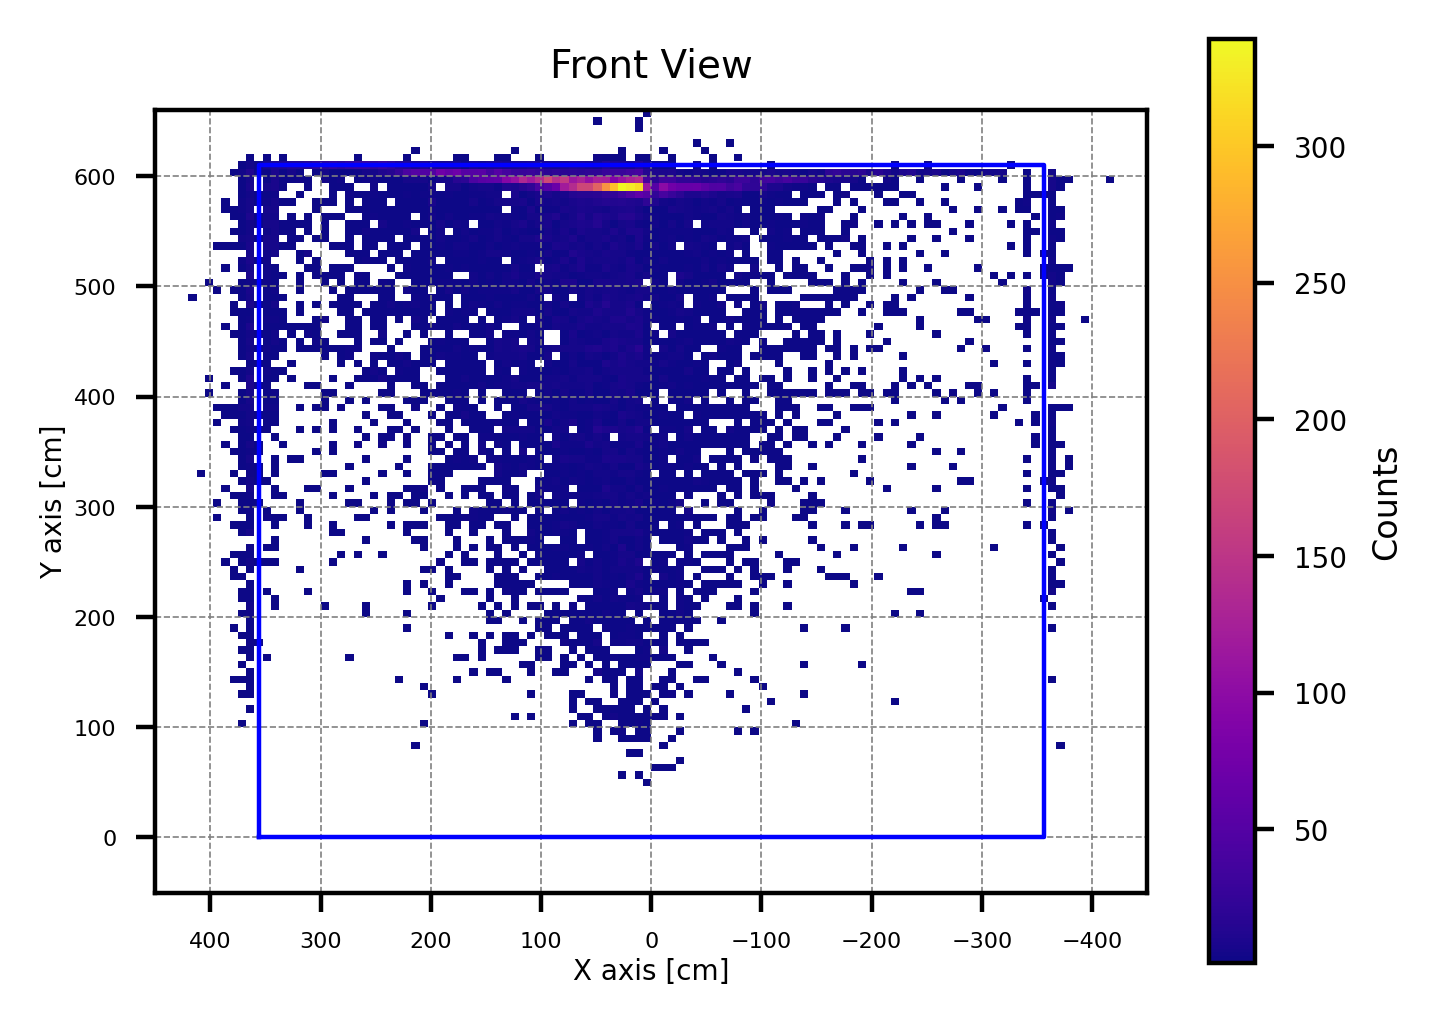

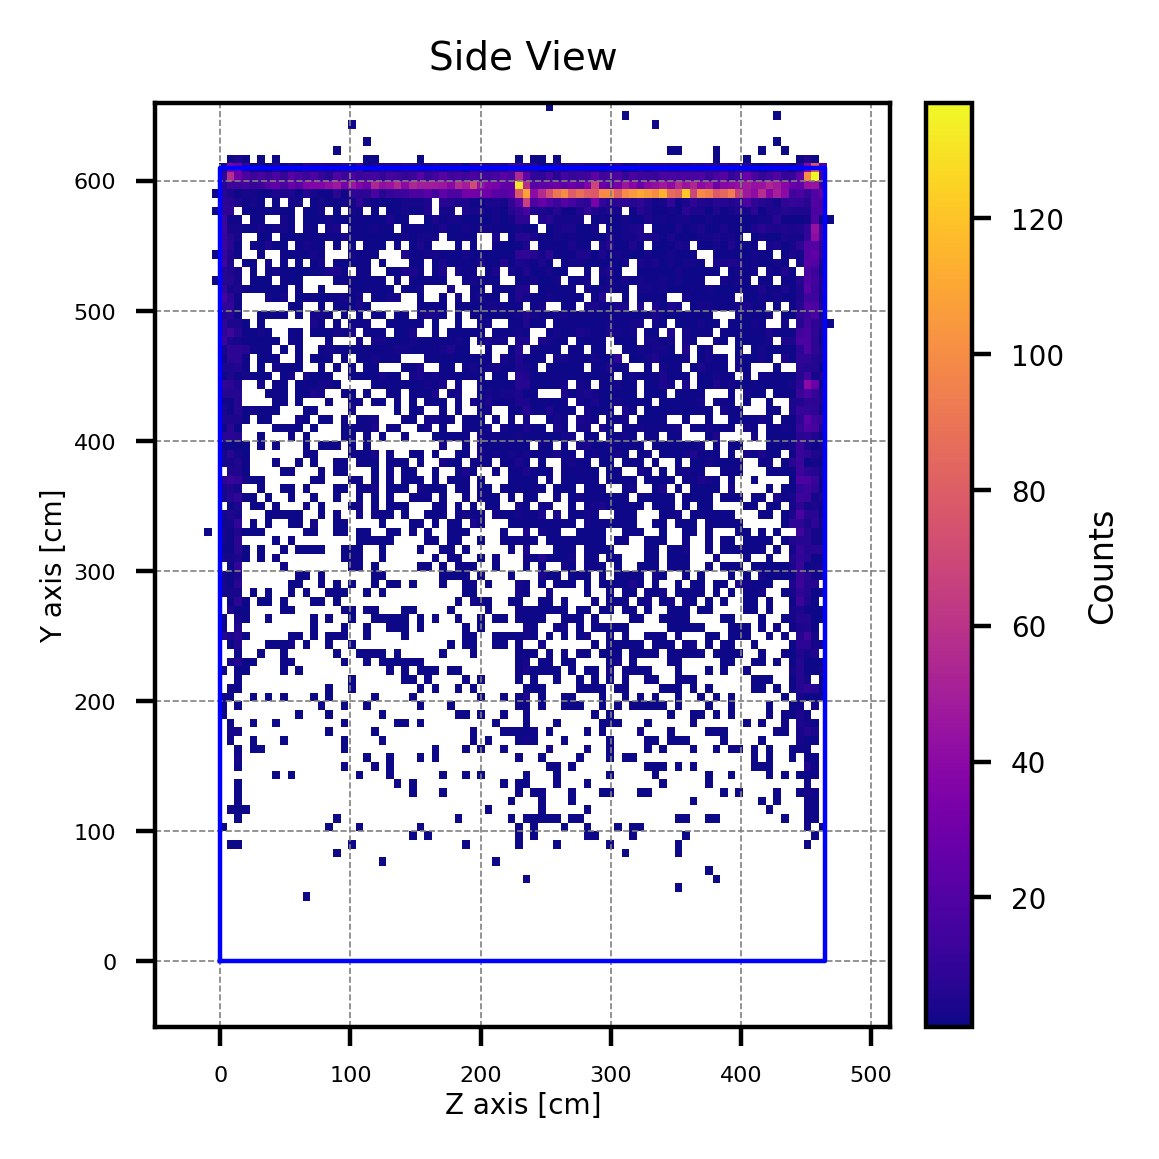

In [25]:
#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_startZ, TPC_startX, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_startX, TPC_startY, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_startZ, TPC_startY, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 

#### Michel Score & Hits:

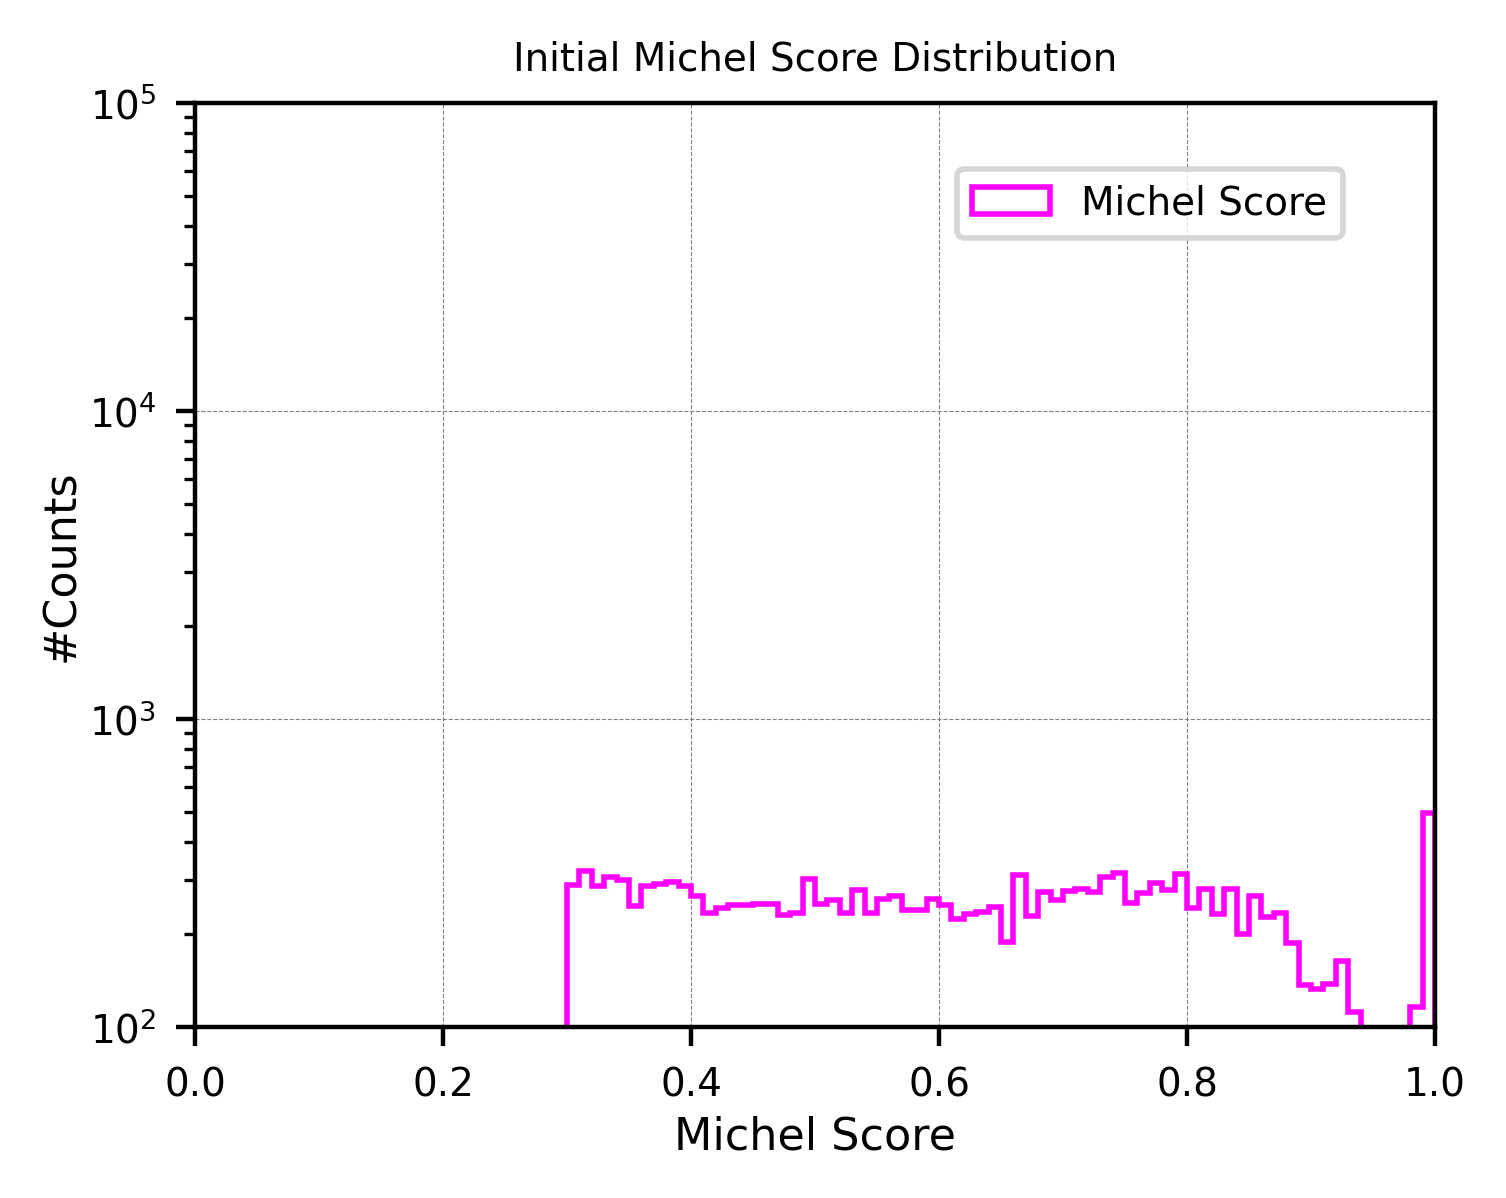

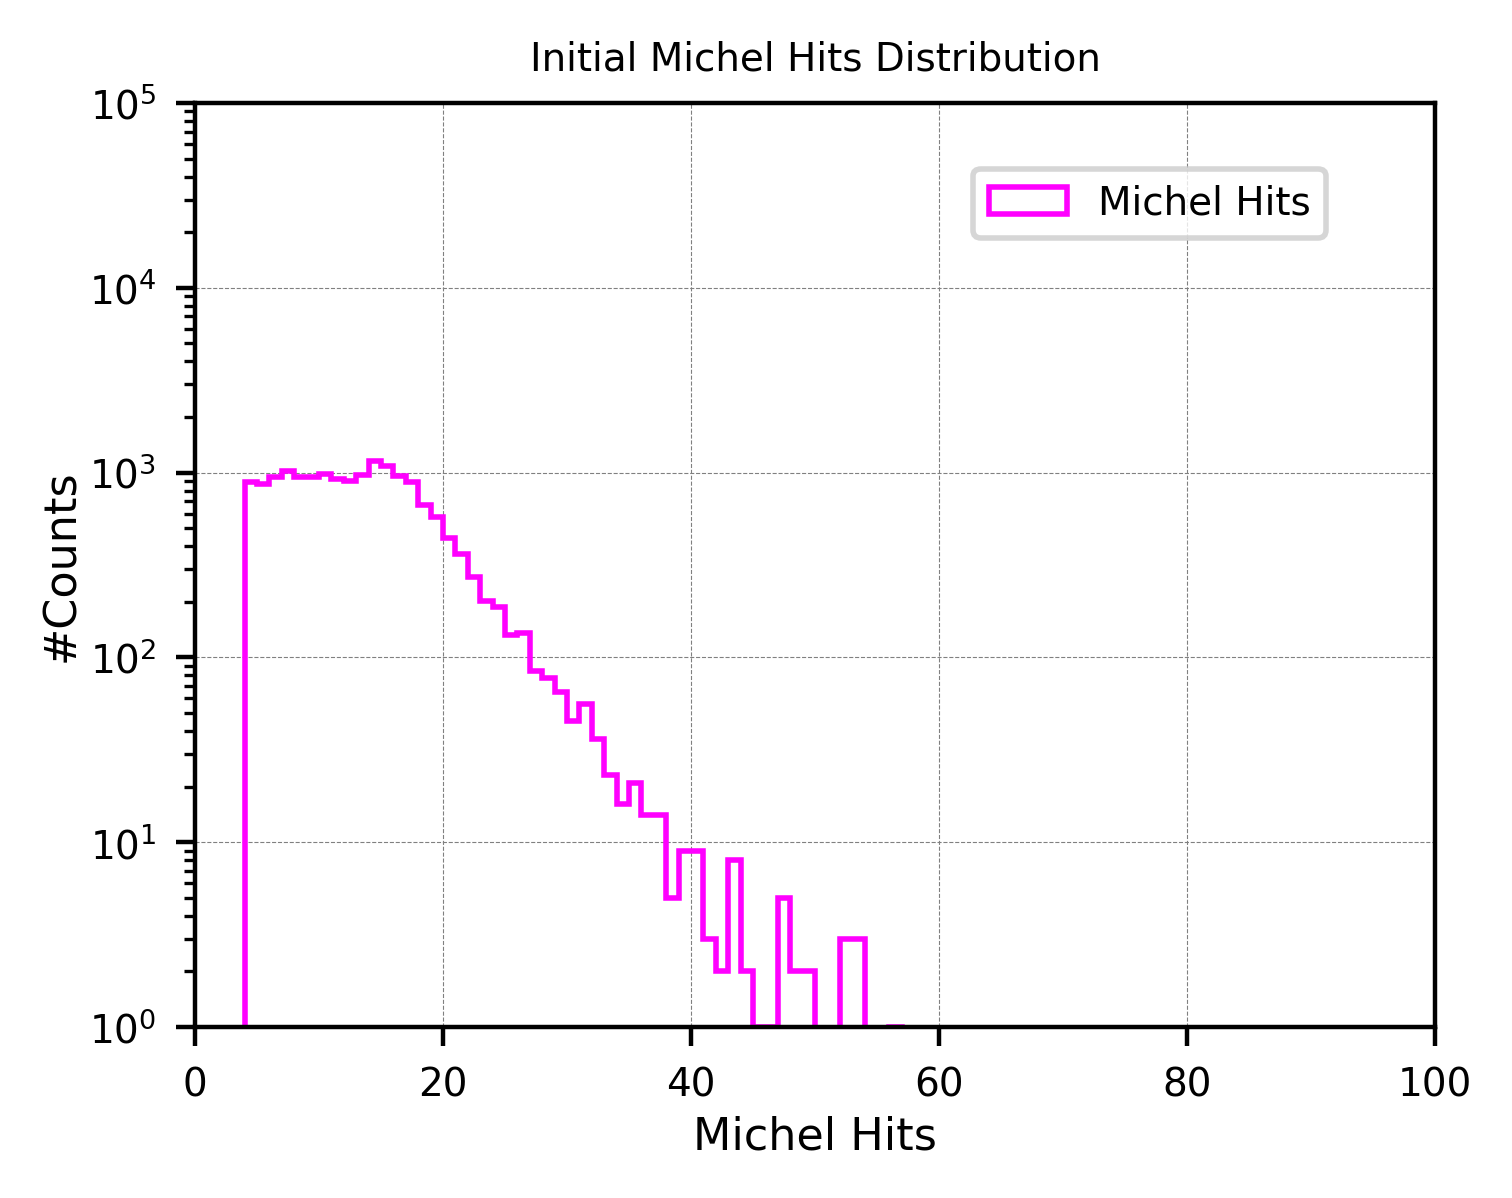

In [26]:
# Michel Score--------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)


#plt.hist(vals_MS_initial, bins=bins, range=(range_min, range_max), edgecolor='black', 
#         histtype='step', linewidth=0.8, label="Initial")
plt.hist(TPC_MS, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=1.0, label="Michel Score")

plt.xlim(0, 1.0)
plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(100, 100000)
plt.yscale('log')
plt.title('Initial Michel Score Distribution', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  





# Michel Hits--------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)


#plt.hist(vals_MH_initial, bins=bins, range=(range_min, range_max), edgecolor='black', 
#         histtype='step', linewidth=0.8, label="Initial")
plt.hist(TPC_MH, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=1.0, label="Michel Hits")


plt.xlim(0, 100)
plt.xlabel('Michel Hits', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(1, 100000)
plt.yscale('log')
plt.title('Initial Michel Hits Distribution', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  